<a href="https://colab.research.google.com/github/TrippleA001/DSN-30-days-of-learning-2025/blob/Personal/Machine%20Learning%20with%20Python%20and%20%20Azure/01_Flights_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flights Data Exploration Challenge

In this challenge, you'll explore a real-world dataset containing flights data from the US Department of Transportation.

Let's start by loading and viewing the data.

In [46]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Fetch data into DataFrame
!wget https://raw.githubusercontent.com/MicrosoftDocs/ml-basics/ee7bccccf5dd1a95f9d547b2e9e5fd68f61fe02e/challenges/data/flights.csv

df_flights = pd.read_csv('flights.csv')
df_flights.head()

--2025-08-08 02:06:46--  https://raw.githubusercontent.com/MicrosoftDocs/ml-basics/ee7bccccf5dd1a95f9d547b2e9e5fd68f61fe02e/challenges/data/flights.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35862658 (34M) [text/plain]
Saving to: ‘flights.csv.1’

flights.csv.1       100%[===================>]  34.20M  --.-KB/s    in 0.1s    

2025-08-08 02:06:47 (264 MB/s) - ‘flights.csv.1’ saved [35862658/35862658]



,Year,Month,DayofMonth,DayOfWeek,Carrier,OriginAirportID,OriginAirportName,OriginCity,OriginState,DestAirportID,DestAirportName,DestCity,DestState,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
0,2013,9,16,1,DL,15304,Tampa International,Tampa,FL,12478,John F. Kennedy International,New York,NY,1539,4,0.0,1824,13,0,0
1,2013,9,23,1,WN,14122,Pittsburgh International,Pittsburgh,PA,13232,Chicago Midway International,Chicago,IL,710,3,0.0,740,22,1,0
2,2013,9,7,6,AS,14747,Seattle/Tacoma International,Seattle,WA,11278,Ronald Reagan Washington National,Washington,DC,810,-3,0.0,1614,-7,0,0
3,2013,7,22,1,OO,13930,Chicago O'Hare International,Chicago,IL,11042,Cleveland-Hopkins International,Cleveland,OH,804,35,1.0,1027,33,1,0
4,2013,5,16,4,DL,13931,Norfolk International,Norfolk,VA,10397,Hartsfield-Jackson Atlanta International,Atlanta,GA,545,-1,0.0,728,-9,0,0


The dataset contains observations of US domestic flights in 2013, and consists of the following fields:

- **Year**: The year of the flight (all records are from 2013)
- **Month**: The month of the flight
- **DayofMonth**: The day of the month on which the flight departed
- **DayOfWeek**: The day of the week on which the flight departed - from 1 (Monday) to 7 (Sunday)
- **Carrier**: The two-letter abbreviation for the airline.
- **OriginAirportID**: A unique numeric identifier for the departure aiport
- **OriginAirportName**: The full name of the departure airport
- **OriginCity**: The departure airport city
- **OriginState**: The departure airport state
- **DestAirportID**: A unique numeric identifier for the destination aiport
- **DestAirportName**: The full name of the destination airport
- **DestCity**: The destination airport city
- **DestState**: The destination airport state
- **CRSDepTime**: The scheduled departure time
- **DepDelay**: The number of minutes departure was delayed (flight that left ahead of schedule have a negative value)
- **DelDelay15**: A binary indicator that departure was delayed by more than 15 minutes (and therefore considered "late")
- **CRSArrTime**: The scheduled arrival time
- **ArrDelay**: The number of minutes arrival was delayed (flight that arrived ahead of schedule have a negative value)
- **ArrDelay15**: A binary indicator that arrival was delayed by more than 15 minutes (and therefore considered "late")
- **Cancelled**: A binary indicator that the flight was cancelled

Your challenge is to explore the flight data to analyze possible factors that affect delays in departure or arrival of a flight.

1. Start by cleaning the data.
    - Identify any null or missing data, and impute appropriate replacement values.
    - Identify and eliminate any outliers in the **DepDelay** and **ArrDelay** columns.
2. Explore the cleaned data.
    - View summary statistics for the numeric fields in the dataset.
    - Determine the distribution of the **DepDelay** and **ArrDelay** columns.
    - Use statistics, aggregate functions, and visualizations to answer the following questions:
        - *What are the average (mean) departure and arrival delays?*
        - *How do the carriers compare in terms of arrival delay performance?*
        - *Is there a noticable difference in arrival delays for different days of the week?*
        - *Which departure airport has the highest average departure delay?*
        - *Do **late** departures tend to result in longer arrival delays than on-time departures?*
        - *Which route (from origin airport to destination airport) has the most **late** arrivals?*
        - *Which route has the highest average arrival delay?*
        
Add markdown and code cells as required to create your solution.

> **Note**: There is no single "correct" solution. A sample solution is provided in [01 - Flights Challenge.ipynb](01%20-%20Flights%20Solution.ipynb).

In [48]:
# Your code to explore the data

#Data Cleaning

In [49]:
# Check for missing values
df_flights.isnull().sum().to_frame('Missing Values')

,Missing Values
Year,0
Month,0
DayofMonth,0
DayOfWeek,0
Carrier,0
OriginAirportID,0
OriginAirportName,0
OriginCity,0
OriginState,0
DestAirportID,0


<Axes: >

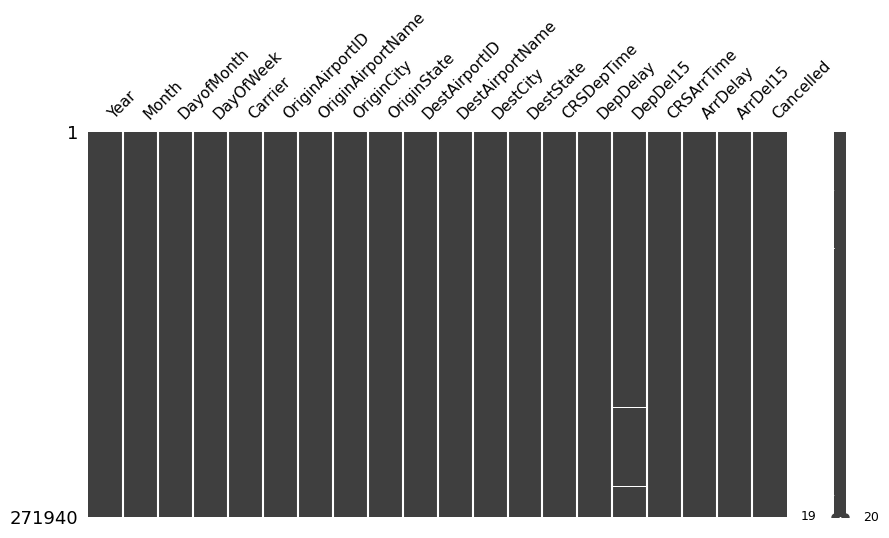

In [50]:
# Visualize missing data
import missingno as msno

# Plot a matrix chart, set chart and font size
msno.matrix(df_flights, figsize=(10,5), fontsize=11)

In [51]:
# Explore relationship between rows that have missing 'DepDel15'
df_flights[df_flights.DepDel15.isnull()]

,Year,Month,DayofMonth,DayOfWeek,Carrier,OriginAirportID,OriginAirportName,OriginCity,OriginState,DestAirportID,DestAirportName,DestCity,DestState,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
171,2013,4,18,4,DL,10397,Hartsfield-Jackson Atlanta International,Atlanta,GA,13930,Chicago O'Hare International,Chicago,IL,835,0,NaN,945,0,1,1
359,2013,5,22,3,OO,11433,Detroit Metro Wayne County,Detroit,MI,13930,Chicago O'Hare International,Chicago,IL,1719,0,NaN,1738,0,1,1
429,2013,7,3,3,MQ,13851,Will Rogers World,Oklahoma City,OK,13930,Chicago O'Hare International,Chicago,IL,1935,0,NaN,2125,0,1,1
545,2013,4,13,6,FL,14524,Richmond International,Richmond,VA,10397,Hartsfield-Jackson Atlanta International,Atlanta,GA,630,0,NaN,809,0,1,1
554,2013,5,8,3,EV,12953,LaGuardia,New York,NY,11193,Cincinnati/Northern Kentucky International,Cincinnati,OH,1320,0,NaN,1524,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271410,2013,8,5,1,WN,14831,Norman Y. Mineta San Jose International,San Jose,CA,10800,Bob Hope,Burbank,CA,1525,0,NaN,1625,0,1,1
271607,2013,6,18,2,EV,14100,Philadelphia International,Philadelphia,PA,13244,Memphis International,Memphis,TN,600,0,NaN,729,0,1,1
271634,2013,5,8,3,AA,11298,Dallas/Fort Worth International,Dallas/Fort Worth,TX,14100,Philadelphia International,Philadelphia,PA,1325,0,NaN,1745,0,1,1
271671,2013,10,8,2,WN,12892,Los Angeles International,Los Angeles,CA,12889,McCarran International,Las Vegas,NV,1440,0,NaN,1540,0,1,1


In [52]:
#Check relationship between 'DepDelay' and 'DepDel15'
df_flights[df_flights.DepDelay == 0]

,Year,Month,DayofMonth,DayOfWeek,Carrier,OriginAirportID,OriginAirportName,OriginCity,OriginState,DestAirportID,DestAirportName,DestCity,DestState,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
20,2013,9,23,1,WN,12191,William P Hobby,Houston,TX,10821,Baltimore/Washington International Thurgood Ma...,Baltimore,MD,655,0,0.0,1055,-16,0,0
49,2013,5,6,1,WN,14869,Salt Lake City International,Salt Lake City,UT,11292,Denver International,Denver,CO,1120,0,0.0,1245,-2,0,0
67,2013,8,15,4,WN,12892,Los Angeles International,Los Angeles,CA,15376,Tucson International,Tucson,AZ,940,0,0.0,1100,-3,0,0
69,2013,5,6,1,WN,11259,Dallas Love Field,Dallas,TX,13198,Kansas City International,Kansas City,MO,2055,0,0.0,2220,-5,0,0
71,2013,7,7,7,B6,14843,Luis Munoz Marin International,San Juan,PR,11697,Fort Lauderdale-Hollywood International,Fort Lauderdale,FL,1125,0,0.0,1405,15,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271858,2013,7,3,3,US,11057,Charlotte Douglas International,Charlotte,NC,10721,Logan International,Boston,MA,2007,0,0.0,2215,1,0,0
271868,2013,10,7,1,OO,12266,George Bush Intercontinental/Houston,Houston,TX,11259,Dallas Love Field,Dallas,TX,2027,0,0.0,2135,-16,0,0
271885,2013,5,15,3,US,14771,San Francisco International,San Francisco,CA,14100,Philadelphia International,Philadelphia,PA,1059,0,NaN,1918,0,1,1
271919,2013,5,6,1,MQ,13930,Chicago O'Hare International,Chicago,IL,10693,Nashville International,Nashville,TN,1655,0,0.0,1820,-4,0,0


In [53]:
# Verify that all 'DepDel15' missing values have 0 DepDelay
df_flights[df_flights.DepDel15.isnull()].DepDelay.value_counts()

,count
DepDelay,
0,2761


In [54]:
# Fill missing 'DepDel15' values with 0
df_flights.fillna({"DepDel15":0}, inplace=True)

#Verify that there are no missing values
df_flights.isnull().sum().to_frame('Missing Values')

,Missing Values
Year,0
Month,0
DayofMonth,0
DayOfWeek,0
Carrier,0
OriginAirportID,0
OriginAirportName,0
OriginCity,0
OriginState,0
DestAirportID,0


In [55]:
# Check for outliers
df_flights.describe()

,Year,Month,DayofMonth,DayOfWeek,OriginAirportID,DestAirportID,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
count,271940.0,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000
mean,2013.0,6.978514,15.814775,3.899316,12744.899584,12739.136493,1325.498713,10.350449,0.199092,1505.477819,6.496650,0.215930,0.010723
std,0.0,1.982431,8.799033,1.987219,1501.199773,1502.569949,470.748546,35.673710,0.399318,493.204020,38.230331,0.411467,0.102995
min,2013.0,4.000000,1.000000,1.000000,10140.000000,10140.000000,1.000000,-63.000000,0.000000,1.000000,-75.000000,0.000000,0.000000
25%,2013.0,5.000000,8.000000,2.000000,11292.000000,11292.000000,920.000000,-4.000000,0.000000,1119.000000,-11.000000,0.000000,0.000000
50%,2013.0,7.000000,16.000000,4.000000,12892.000000,12892.000000,1320.000000,-1.000000,0.000000,1529.000000,-3.000000,0.000000,0.000000
75%,2013.0,9.000000,23.000000,6.000000,14057.000000,14057.000000,1725.000000,9.000000,0.000000,1918.000000,10.000000,0.000000,0.000000
max,2013.0,10.000000,31.000000,7.000000,15376.000000,15376.000000,2359.000000,1425.000000,1.000000,2359.000000,1440.000000,1.000000,1.000000


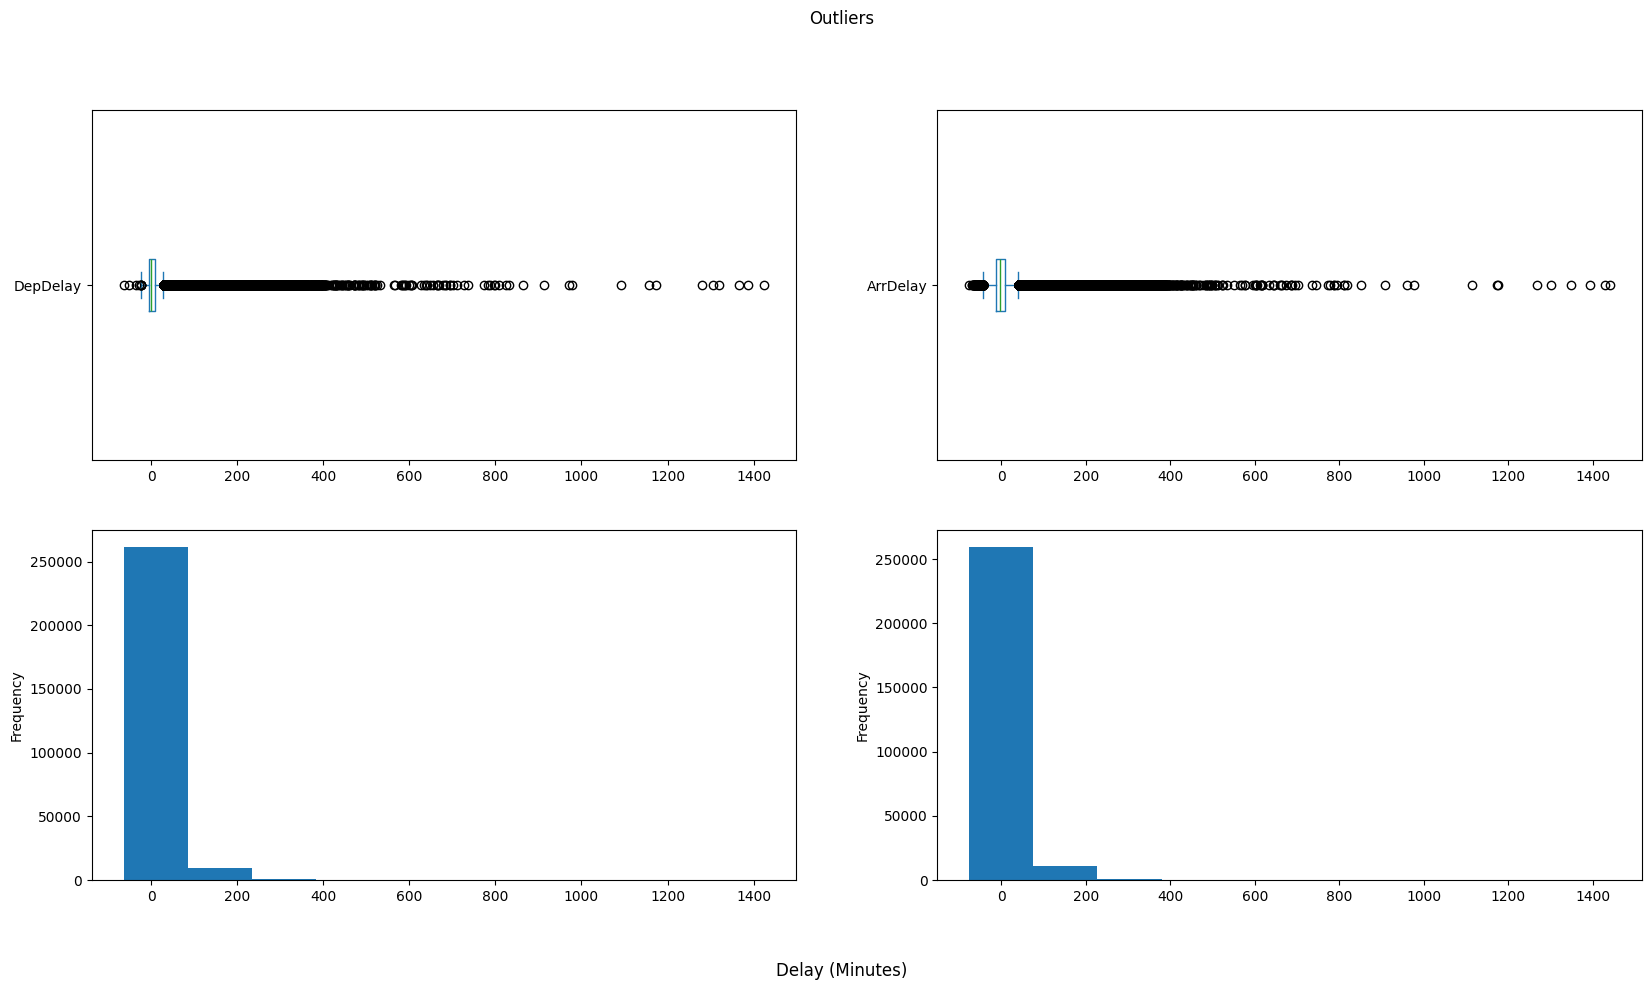

In [56]:
# Visualize outliers in 'DepDelay' and 'ArrDelay'
fig, ax = plt.subplots(2,2, figsize=(20,10))
df_flights.DepDelay.plot(kind='box', vert=False, ax=ax[0, 0])
df_flights.ArrDelay.plot(kind='box', vert=False, ax=ax[0, 1])
df_flights.DepDelay.plot(kind='hist', ax=ax[1, 0])
df_flights.ArrDelay.plot(kind='hist', ax=ax[1, 1])
fig.suptitle('Outliers')
fig.supxlabel('Delay (Minutes)')

plt.show()

In [57]:
df_flights["DepDelay"].value_counts().sort_values()[:50]

,count
DepDelay,
914,1
510,1
773,1
694,1
1386,1
494,1
664,1
695,1
517,1


In [58]:
df_flights["ArrDelay"].value_counts().sort_values()[:50]

,count
ArrDelay,
454,1
795,1
-65,1
337,1
745,1
1175,1
410,1
396,1
402,1


In [75]:
# Remove outliers in 'DepDelay' and 'ArrDelay' using IQR

# Calculate Q1 and Q3 for DepDelay and ArrDelay
Q1_dep = df_flights['DepDelay'].quantile(0.25)
Q3_dep = df_flights['DepDelay'].quantile(0.75)
IQR_dep = Q3_dep - Q1_dep

Q1_arr = df_flights['ArrDelay'].quantile(0.25)
Q3_arr = df_flights['ArrDelay'].quantile(0.75)
IQR_arr = Q3_arr - Q1_arr

# Define bounds for outliers
lower_bound_dep = Q1_dep - 1.5 * IQR_dep
upper_bound_dep = Q3_dep + 1.5 * IQR_dep

lower_bound_arr = Q1_arr - 1.5 * IQR_arr
upper_bound_arr = Q3_arr + 1.5 * IQR_arr

# Remove outliers
df_flights_cleaned_iqr = df_flights[
    (df_flights['DepDelay'] >= lower_bound_dep) & (df_flights['DepDelay'] <= upper_bound_dep) &
    (df_flights['ArrDelay'] >= lower_bound_arr) & (df_flights['ArrDelay'] <= upper_bound_arr)
]

display(df_flights_cleaned.describe())

,Year,Month,DayofMonth,DayOfWeek,OriginAirportID,DestAirportID,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
count,265373.0,265373.000000,265373.000000,265373.000000,265373.000000,265373.000000,265373.000000,265373.000000,265373.000000,265373.000000,265373.000000,265373.000000,265373.000000
mean,2013.0,6.990003,15.804995,3.901117,12746.581864,12739.644858,1320.075686,6.238261,0.179366,1500.292513,2.208695,0.196527,0.010917
std,0.0,1.987058,8.809031,1.989264,1502.359475,1503.355507,470.763952,20.082005,0.383660,492.442900,23.360522,0.397372,0.103911
min,2013.0,4.000000,1.000000,1.000000,10140.000000,10140.000000,1.000000,-63.000000,0.000000,1.000000,-75.000000,0.000000,0.000000
25%,2013.0,5.000000,8.000000,2.000000,11292.000000,11292.000000,915.000000,-4.000000,0.000000,1115.000000,-12.000000,0.000000,0.000000
50%,2013.0,7.000000,16.000000,4.000000,12892.000000,12892.000000,1315.000000,-1.000000,0.000000,1523.000000,-3.000000,0.000000,0.000000
75%,2013.0,9.000000,23.000000,6.000000,14057.000000,14057.000000,1720.000000,8.000000,0.000000,1915.000000,8.000000,0.000000,0.000000
max,2013.0,10.000000,31.000000,7.000000,15376.000000,15376.000000,2359.000000,117.000000,1.000000,2359.000000,121.000000,1.000000,1.000000


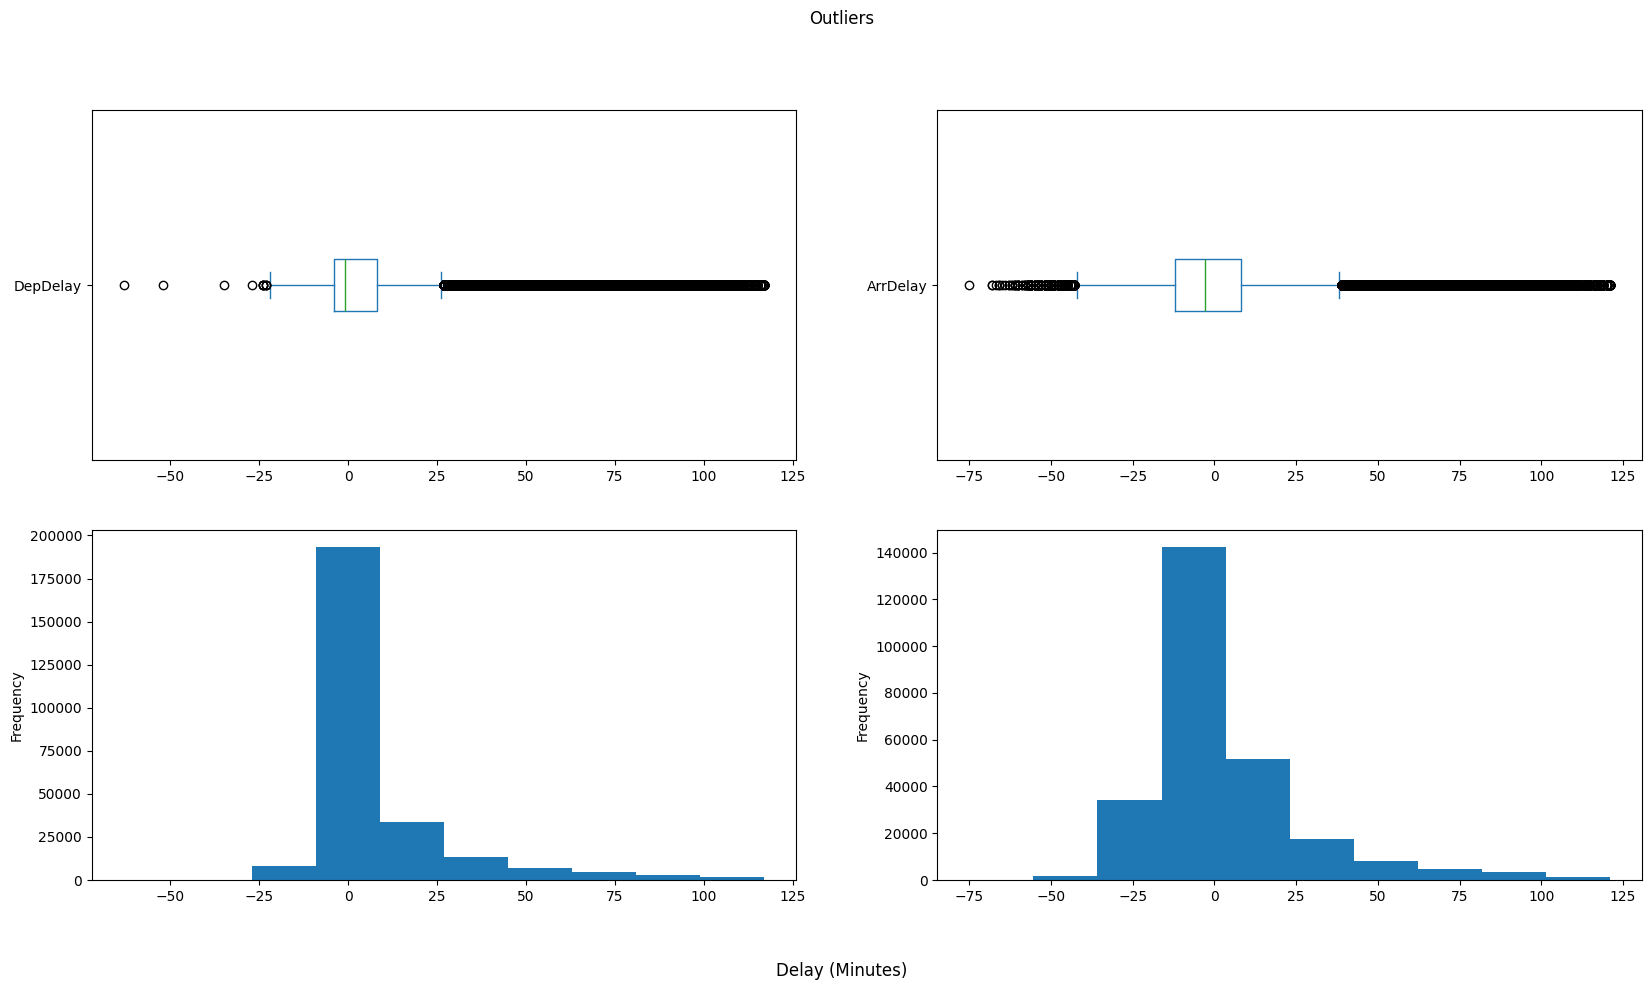

In [77]:
# Visualize distriution of cleaned 'DepDelay' and 'ArrDelay'
fig, ax = plt.subplots(2,2, figsize=(20,10))
df_flights_cleaned.DepDelay.plot(kind='box', vert=False, ax=ax[0, 0])
df_flights_cleaned.ArrDelay.plot(kind='box', vert=False, ax=ax[0, 1])
df_flights_cleaned.DepDelay.plot(kind='hist', ax=ax[1, 0])
df_flights_cleaned.ArrDelay.plot(kind='hist', ax=ax[1, 1])
fig.suptitle('Outliers')
fig.supxlabel('Delay (Minutes)')

plt.show()

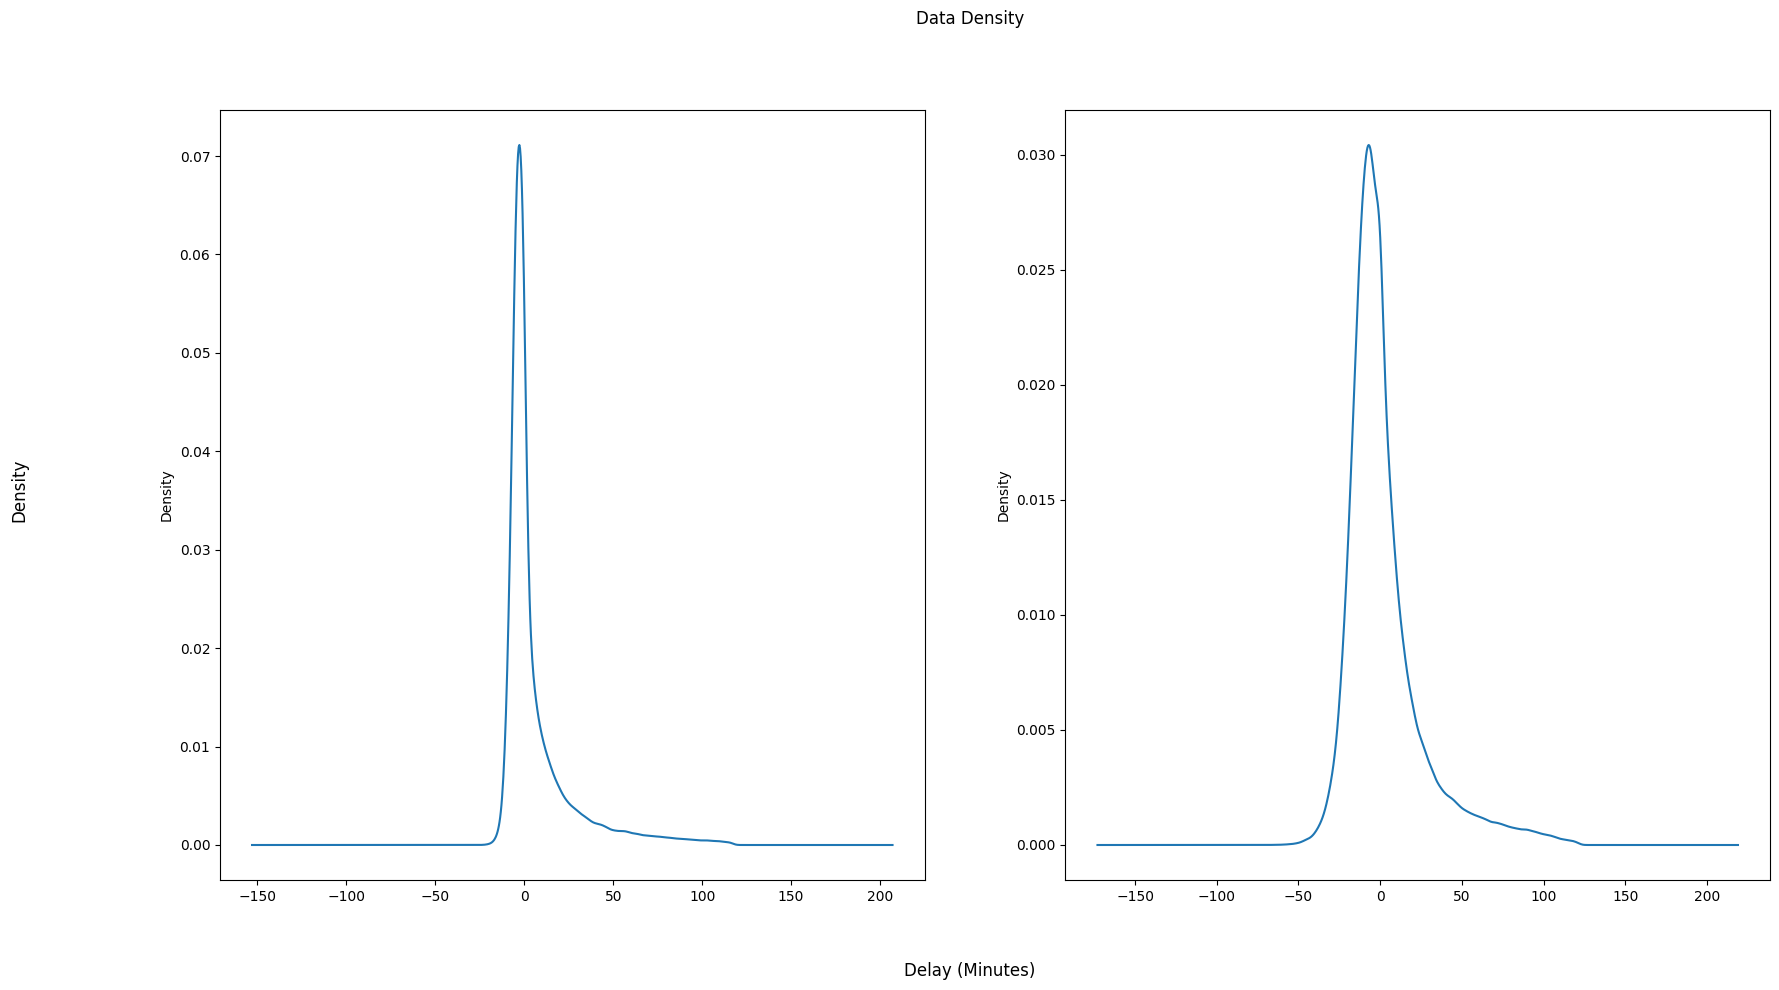

In [80]:
# Visualize density function for cleaned 'DepDelay' and 'ArrDelay'
fig, ax = plt.subplots(1,2, figsize=(20,10))
df_flights_cleaned.DepDelay.plot(kind='density', ax=ax[0])
df_flights_cleaned.ArrDelay.plot(kind='density', ax=ax[1])
fig.suptitle('Data Density')
fig.supxlabel('Delay (Minutes)')
fig.supylabel('Density')
plt.show()


Explore the cleaned data.
View summary statistics for the numeric fields in the dataset.
Determine the distribution of the DepDelay and ArrDelay columns.
Use statistics, aggregate functions, and visualizations to answer the following questions:
What are the average (mean) departure and arrival delays?
How do the carriers compare in terms of arrival delay performance?
Is there a noticable difference in arrival delays for different days of the week?
Which departure airport has the highest average departure delay?
Do late departures tend to result in longer arrival delays than on-time departures?
Which route (from origin airport to destination airport) has the most late arrivals?
Which route has the highest average arrival dela

In [81]:
# Average 'DepDelay' and 'ArrDelay'
avgDepDelay = df_flights_cleaned.DepDelay.mean()
avgArrDelay = df_flights_cleaned.ArrDelay.mean()
print(f"Average Departure Delay: {avgDepDelay}")
print(f"Average Arrival Delay: {avgArrDelay}")


Average Departure Delay: 6.238260863011686
Average Arrival Delay: 2.208694931285398


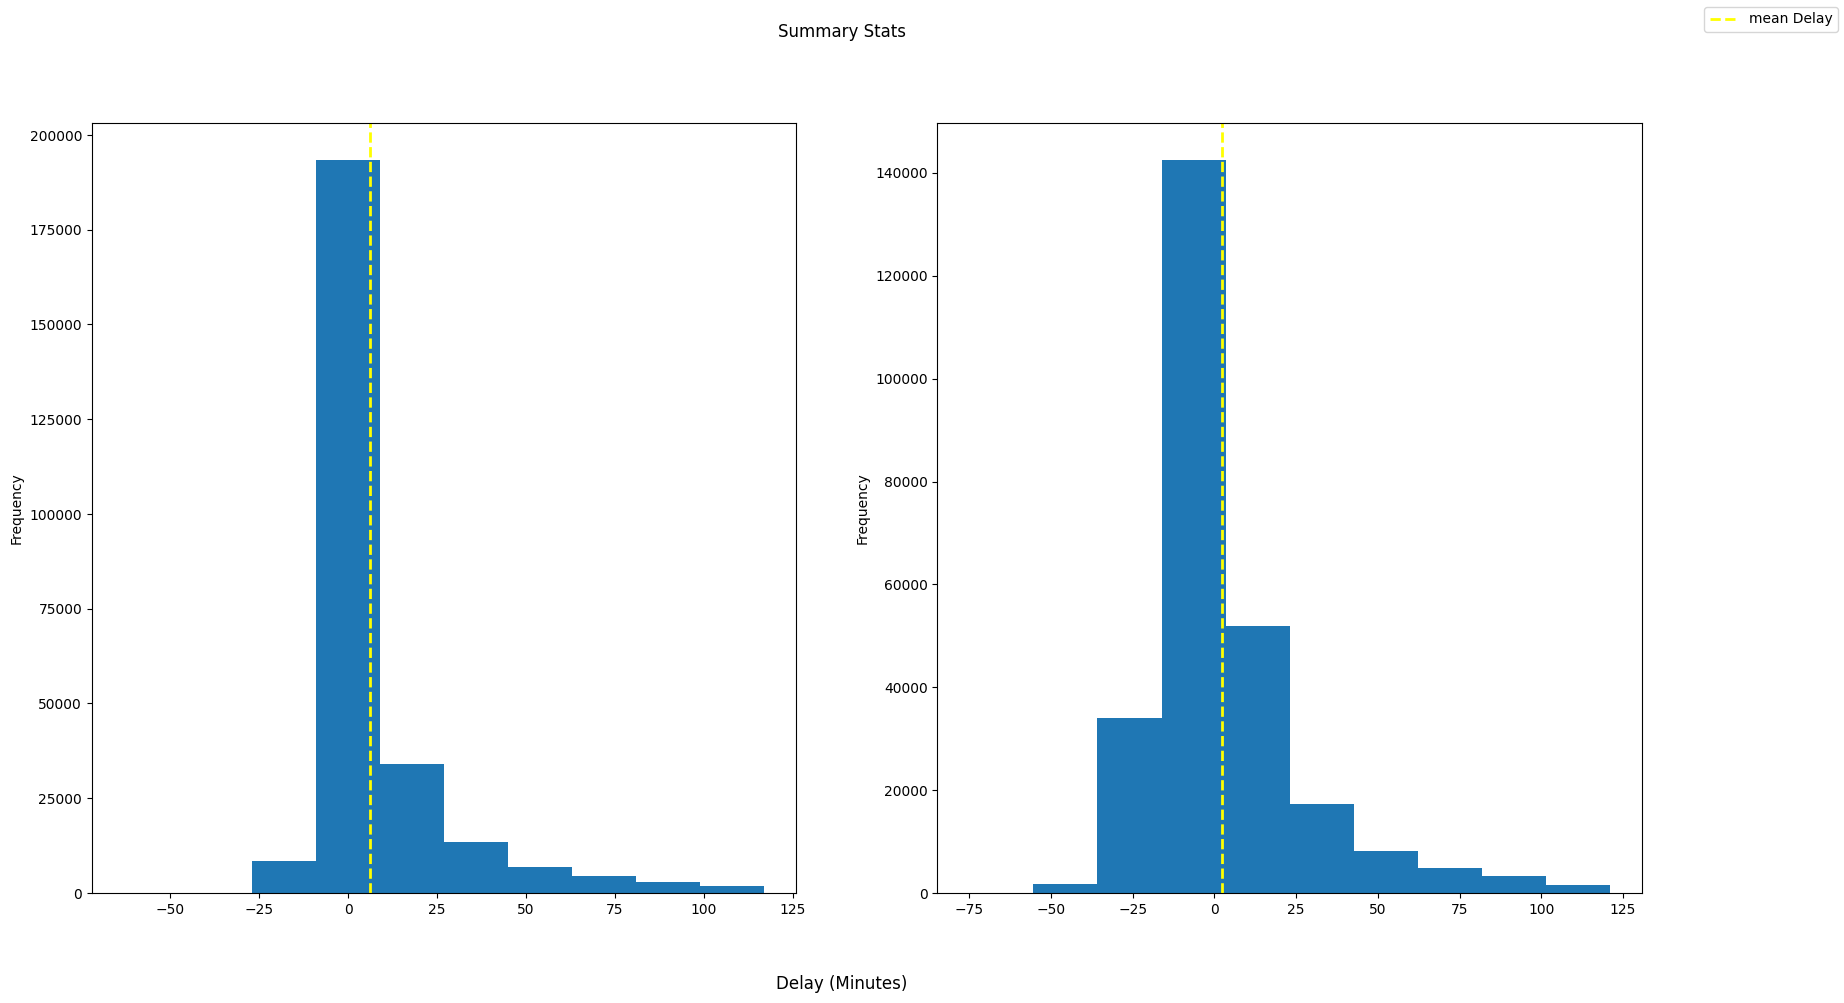

In [92]:
# Visualize distriution of cleaned 'DepDelay' and 'ArrDelay'
fig, ax = plt.subplots(1,2, figsize=(20,10))
df_flights_cleaned.DepDelay.plot(kind='hist', ax=ax[0])
line_dep = ax[0].axvline(avgDepDelay, color='yellow',  linestyle='dashed', linewidth = 2)
df_flights_cleaned.ArrDelay.plot(kind='hist', ax=ax[1])
line_arr = ax[1].axvline(avgArrDelay, color='yellow',  linestyle='dashed', linewidth = 2)

fig.suptitle('Summary Stats')
fig.supxlabel('Delay (Minutes)')
fig.legend(handles=[line_dep], labels=['mean Delay'], loc='upper right') # Add single legend for the mean
plt.show()